In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from vizman import viz
import os
import re 

import pickle

from config import COLORS, COLOR_SCHEME, LABEL_MAP, gray_cmap, bone_white, half_black, emp_dataset_and_experiment_pairs

In [ ]:
# Generate output folder
output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis")
output_folder.mkdir(exist_ok=True)

# Load data 
with open(output_folder / "all_datasets_filtered.pkl", "rb") as f:
    dict_with_all_datasets = pickle.load(f)
    
# Folder now changed for saving 
output_folder = output_folder / "spiders"
output_folder.mkdir(exist_ok=True)


In [ ]:
# Taxonomies 
info_mami = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/04_further_info/names_of_animals_with_preprocessed_connectomes_50_processed_removed_95.csv")
print(info_mami.columns)

Index(['Unnamed: 0', 'animal', 'common_name', 'name', 'species', 'genus',
       'sub_family', 'family', 'sub_order', 'order', 'super_order',
       'phylogenetic_group', 'brain_weight_g', 'brain_volume_cm3',
       'brain_data_source'],
      dtype='object')


In [ ]:
dict_with_all_datasets.keys()

dict_keys(['hcp_schaefer_100_dataset_gnm', 'hcp_schaefer_100_dataset', 'kaysons_generated_networks_diffusion', 'kaysons_generated_networks_propagation', 'kaysons_generated_networks_routing', 'kaysons_generated_networks_topology', 'suarez_MaMI_dataset'])

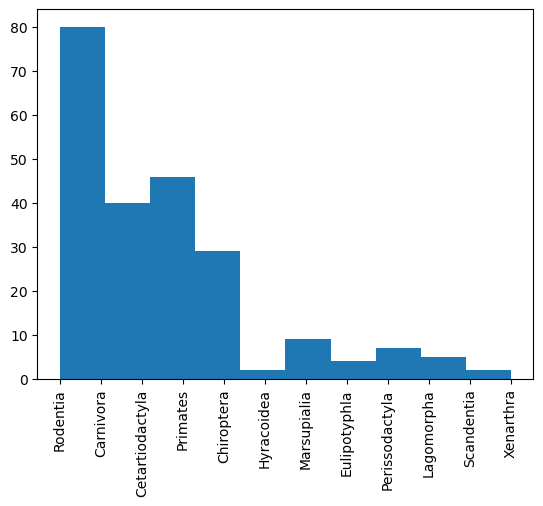

In [ ]:
plt.hist(info_mami["order"])
plt.xticks(rotation=90)
plt.show()

In [ ]:
# dict_with_all_datasets['suarez_MaMI_dataset'].

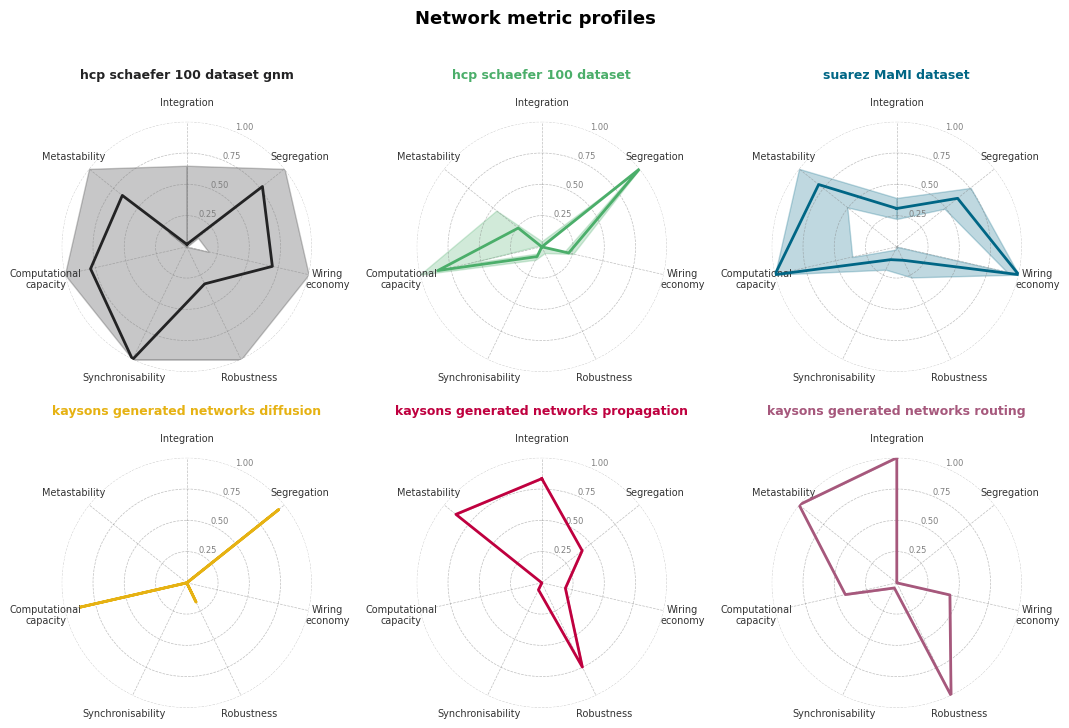

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
import pandas as pd

# ── 1. Select your six metrics ────────────────────────────────────────────────
# SELECTED_COLS = [
#     "global_efficiency",
#     "modularity", 
#     "" 
    
#     'char_path_length',
#     'avg_communicability',
#     'wiring_cost',
#     'algebraic_connectivity_fiedler_value',
#     'targeted_attack_robustness_rob_ratio',
#     'persistent_homology_ph_total_persistence',
# ]

selected_properties = {
    "Integration": ["global_efficiency"], # , "char_path_length"],
    "Segregation": ["modularity"], # , "avg_communicability"],
    "Wiring\neconomy": ["proportion_long_range_connections_0.5"], # "wiring_cost", "algebraic_connectivity_fiedler_value"],
    "Robustness": ["synchronizability_eigenratio_lambda_2"], # "targeted_attack_robustness_rob_ratio", "persistent_homology_ph_total_persistence"],
    "Synchronisability": ["synchronizability_eigenratio_eigenratio"], # "synchronisability", "synchronisability_normalised"],
    "Computational\ncapacity": ["computational_capacity_total_capacity"], # "computational_capacity", "computational_capacity_normalised"],
    "Metastability": ["kuramoto_averaged_synchronization_r_std"], # "metastability", "metastability_normalised"],
}
    
SELECTED_COLS = []
for prop, metrics in selected_properties.items():
    if metrics:
        SELECTED_COLS.extend(metrics)
    else:
        print(f"Warning: No metrics selected for property '{prop}'")
        
# create mapping from metric to property for later labelling
# METRIC_TO_PROPERTY = {}
# for prop, metrics in selected_properties.items():
#     for metric in metrics:
#         METRIC_TO_PROPERTY[metric] = prop

N_SAMPLE = 100
SEED     = 42

# ── 2. Sample & aggregate ─────────────────────────────────────────────────────
def get_stats(df, cols, n_sample, seed):
    """Return (mean_series, std_series) for the selected cols."""
    sub = df[cols].dropna()
    if len(sub) > n_sample:
        sub = sub.sample(n_sample, random_state=seed)
    return sub.mean(), sub.std(ddof=0).fillna(0)


datasets_to_look_at = ['hcp_schaefer_100_dataset_gnm', 
                       'hcp_schaefer_100_dataset', 
                       'suarez_MaMI_dataset',
                       'kaysons_generated_networks_diffusion', 
                       'kaysons_generated_networks_propagation', 
                       'kaysons_generated_networks_routing', 
                    #    'kaysons_generated_networks_topology', 
                       ]
stats = {}
for name in datasets_to_look_at: # df in dict_with_all_datasets.items():
    df = dict_with_all_datasets[name]
    stats[name] = get_stats(df, SELECTED_COLS, N_SAMPLE, SEED)



# ── 3. Normalise across ALL datasets so axes are [0, 1] ──────────────────────
all_means = pd.DataFrame({k: v[0] for k, v in stats.items()}).T   # datasets × cols
col_min   = all_means.min()
col_max   = all_means.max()
col_range = (col_max - col_min).replace(0, 1)   # avoid /0
COL_RANGE = col_range
COL_MIN = col_min


def normalise(series):
    return (series - COL_MIN) / COL_RANGE


# ── 4. Spider-plot helper ─────────────────────────────────────────────────────
def make_spider(ax, values, errors, labels, color, title, alpha_fill=0.20):
    N = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]                        # close the loop

    vals = list(values) + [values[0]]
    errs = list(errors) + [errors[0]]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.plot(angles, vals, color=color, linewidth=2)
    # ax.fill(angles, vals, color=color, alpha=alpha_fill)

    # ±1 std shaded band
    upper = np.clip(np.array(vals) + np.array(errs), 0, 1)
    lower = np.clip(np.array(vals) - np.array(errs), 0, 1)
    ax.fill_between(angles, lower, upper, color=color, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(
        [l.replace('_', '\n') for l in labels],
        fontsize=7, color='#333333'
    )
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=6, color='grey')
    ax.set_title(title, fontsize=9, fontweight='bold', pad=14,
                 color=color, wrap=True)
    ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.spines['polar'].set_visible(False)



# ── 5. Draw ───────────────────────────────────────────────────────────────────
n_datasets = len(stats)
# PALETTE    = plt.cm.tab10.colors

ncols = 3
nrows = int(np.ceil(n_datasets / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 3.6, nrows * 3.6),
    subplot_kw=dict(polar=True)
)
axes_flat = np.array(axes).flatten()

for idx, (name, (mean_raw, std_raw)) in enumerate(stats.items()):
    mean_n = normalise(mean_raw).values
    std_n  = (std_raw / col_range).values          # scale std the same way
    color  = COLOR_SCHEME[name] # PALETTE[idx % len(PALETTE)]

    make_spider(
        ax     = axes_flat[idx],
        values = mean_n,
        errors = std_n,
        labels = selected_properties.keys(), # SELECTED_COLS,
        color  = color,
        title  = name.replace('_', ' '),
    )

# hide unused axes
for ax in axes_flat[n_datasets:]:
    ax.set_visible(False)

fig.suptitle('Network metric profiles', #  (normalised) - mean ± std',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig('spider_plots.png', dpi=150, bbox_inches='tight')
plt.show()

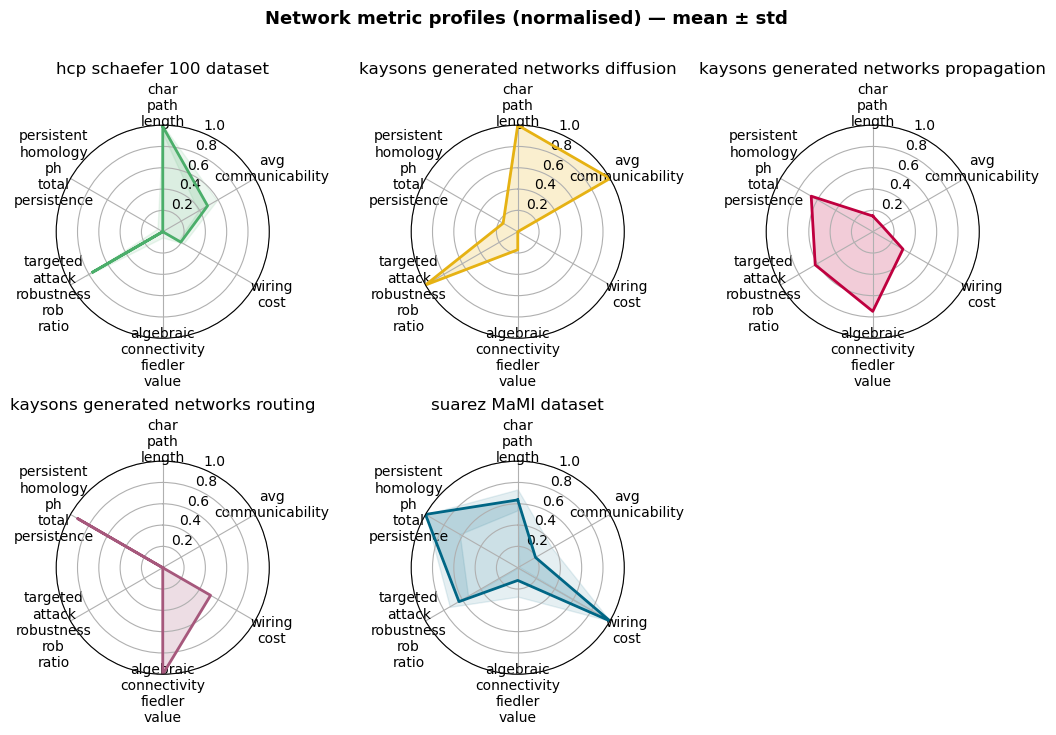

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
import pandas as pd

# ── 1. Select your six metrics ────────────────────────────────────────────────
SELECTED_COLS = [
    'char_path_length',
    'avg_communicability',
    'wiring_cost',
    'algebraic_connectivity_fiedler_value',
    'targeted_attack_robustness_rob_ratio',
    'persistent_homology_ph_total_persistence',
]

N_SAMPLE = 100
SEED     = 42

# ── 2. Sample & aggregate ─────────────────────────────────────────────────────
def get_stats(df, cols, n_sample, seed):
    """Return (mean_series, std_series) for the selected cols."""
    sub = df[cols].dropna()
    if len(sub) > n_sample:
        sub = sub.sample(n_sample, random_state=seed)
    return sub.mean(), sub.std(ddof=0).fillna(0)



stats = {}
for name, df in dict_with_all_datasets.items():
    if name in ['hcp_schaefer_100_dataset_gnm', 'kaysons_generated_networks_topology']: 
        continue  
    stats[name] = get_stats(df, SELECTED_COLS, N_SAMPLE, SEED)



# ── 3. Normalise across ALL datasets so axes are [0, 1] ──────────────────────
all_means = pd.DataFrame({k: v[0] for k, v in stats.items()}).T   # datasets × cols
col_min   = all_means.min()
col_max   = all_means.max()
col_range = (col_max - col_min).replace(0, 1)   # avoid /0


col_range = COL_RANGE
# def normalise(series):
#     return (series - col_min) / col_range


# ── 4. Spider-plot helper ─────────────────────────────────────────────────────
def make_spider(ax, values, errors, labels, color, title, alpha_fill=0.20):
    N = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]                        # close the loop

    vals = list(values) + [values[0]]
    errs = list(errors) + [errors[0]]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.plot(angles, vals, color=color, linewidth=2)
    ax.fill(angles, vals, color=color, alpha=alpha_fill)

    # ±1 std shaded band
    upper = np.clip(np.array(vals) + np.array(errs), 0, 1)
    lower = np.clip(np.array(vals) - np.array(errs), 0, 1)
    ax.fill_between(angles, lower, upper, color=color, alpha=0.10)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(
        [l.replace('_', '\n') for l in labels] # ,
        # fontsize=7, color='#333333'
    )
    ax.set_ylim(0, 1)
    # ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    # ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=6, color='grey')
    ax.set_title(title) # , fontsize=9, fontweight='bold', pad=14,
                #  color=color, wrap=True)
        # ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
    # ax.spines['polar'].set_visible(False)



# ── 5. Draw ───────────────────────────────────────────────────────────────────
n_datasets = len(stats)
# PALETTE    = plt.cm.tab10.colors

ncols = 3
nrows = int(np.ceil(n_datasets / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 3.6, nrows * 3.6),
    subplot_kw=dict(polar=True)
)
axes_flat = np.array(axes).flatten()

for idx, (name, (mean_raw, std_raw)) in enumerate(stats.items()):
    mean_n = normalise(mean_raw).values
    std_n  = (std_raw / col_range).values          # scale std the same way
    color  = COLOR_SCHEME[name] # PALETTE[idx % len(PALETTE)]

    make_spider(
        ax     = axes_flat[idx],
        values = mean_n,
        errors = std_n,
        labels = SELECTED_COLS,
        color  = color,
        title  = name.replace('_', ' '),
    )

# hide unused axes
for ax in axes_flat[n_datasets:]:
    ax.set_visible(False)

fig.suptitle('Network metric profiles (normalised) — mean ± std',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig('spider_plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
dict_with_all_datasets['suarez_MaMI_dataset']

,energy,eta,gamma,id,omega,directed_simplices_count,directed_simplices_max_size,wiring_cost,avg_clustering,degree_assortativity,...,algebraic_connectivity_fiedler_bipartition_balance,persistent_homology_ph_h0_n_features,persistent_homology_ph_h0_persistence_mean,persistent_homology_ph_h0_persistence_std,persistent_homology_ph_h0_entropy,persistent_homology_ph_h1_n_features,persistent_homology_ph_h1_persistence_mean,persistent_homology_ph_h1_persistence_std,persistent_homology_ph_h1_entropy,persistent_homology_ph_total_persistence
0,0.20,2.102041,0.191837,5,0.607249,334.0,5.0,6.885055,0.242105,-0.139680,...,0.20,99.0,1.0,0.0,4.59512,63.0,0.5,0.0,4.143135,130.5
1,0.17,3.000000,0.169388,8,0.583831,319.0,5.0,6.830447,0.243338,0.036338,...,0.14,99.0,1.0,0.0,4.59512,90.0,0.5,0.0,4.499810,144.0
2,0.17,2.551020,0.191837,4,0.501974,297.0,6.0,6.722624,0.290707,-0.098389,...,0.88,99.0,1.0,0.0,4.59512,64.0,0.5,0.0,4.158883,131.0
3,0.16,3.000000,0.281633,4,0.469093,308.0,5.0,6.723156,0.309964,-0.026754,...,0.98,99.0,1.0,0.0,4.59512,53.0,0.5,0.0,3.970292,125.5
4,0.16,2.326531,0.191837,0,0.485175,321.0,5.0,6.338058,0.274466,0.007061,...,1.00,99.0,1.0,0.0,4.59512,64.0,0.5,0.0,4.158883,131.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,0.17,2.775510,0.146939,5,0.489480,271.0,5.0,7.282549,0.300607,-0.038329,...,0.96,99.0,1.0,0.0,4.59512,59.0,0.5,0.0,4.077537,128.5
221,0.16,2.551020,0.124490,0,0.525896,316.0,6.0,7.301747,0.291301,-0.040741,...,0.86,99.0,1.0,0.0,4.59512,65.0,0.5,0.0,4.174387,131.5
222,0.24,1.653061,0.146939,0,0.583410,285.0,6.0,7.416419,0.244901,0.034593,...,0.38,99.0,1.0,0.0,4.59512,89.0,0.5,0.0,4.488636,143.5
223,0.16,2.775510,0.169388,1,0.593756,306.0,6.0,7.489097,0.247813,0.022037,...,0.56,99.0,1.0,0.0,4.59512,105.0,0.5,0.0,4.653960,151.5


In [ ]:
# Remove row 95 
dict_with_all_datasets['suarez_MaMI_dataset'] = dict_with_all_datasets['suarez_MaMI_dataset'][dict_with_all_datasets['suarez_MaMI_dataset'].index != 95]

Animals per phylogenetic_group group:
phylogenetic_group
Xenarthra             1
Other                11
Euarchontoglires     81
Laurasiatheria      131
dtype: int64

→ Minimum group size: 1 (Xenarthra)


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_98942/1552105286.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=N_PER_GROUP, random_state=SEED))


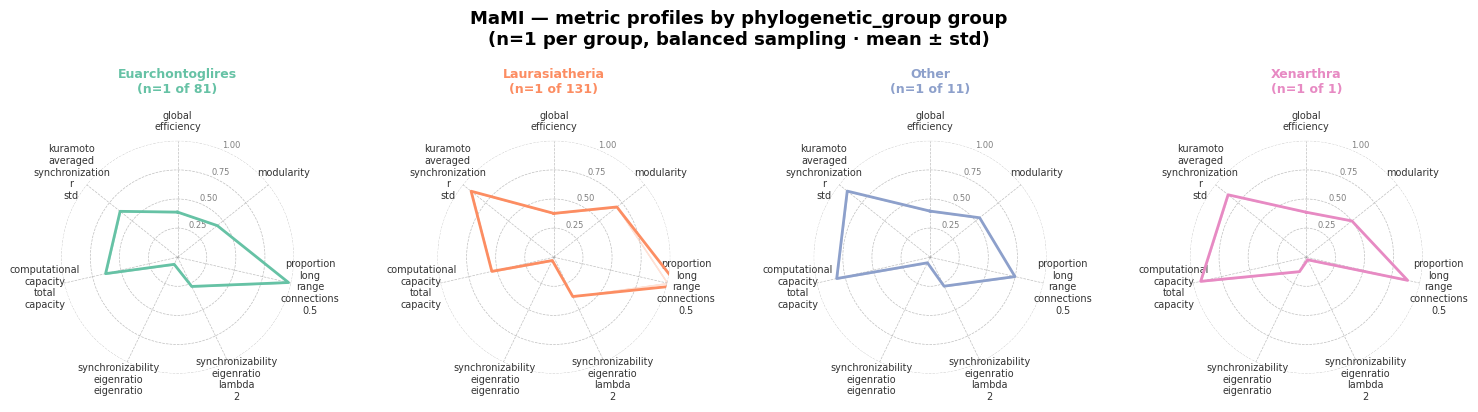

In [ ]:
# ── 1. Merge taxonomy with metric data ────────────────────────────────────────
mami_metrics = dict_with_all_datasets['suarez_MaMI_dataset'][SELECTED_COLS].reset_index(drop=True)
info_mami    = info_mami.reset_index(drop=True)
what_to_look_at = "phylogenetic_group"


# Safety check
assert len(mami_metrics) == len(info_mami), \
    f"Row mismatch: metrics={len(mami_metrics)}, taxonomy={len(info_mami)}"

mami_full = pd.concat([info_mami[['animal', 'common_name', what_to_look_at]], 
                        mami_metrics], axis=1)

# ── 2. Find minimum group size → sample that many per group ──────────────────
group_counts = mami_full.groupby(what_to_look_at).size()
print(f"Animals per {what_to_look_at} group:")
print(group_counts.sort_values())
print(f"\n→ Minimum group size: {group_counts.min()} ({group_counts.idxmin()})")

N_PER_GROUP = group_counts.min()

sampled = (
    mami_full
    .groupby(what_to_look_at, group_keys=False)
    .apply(lambda g: g.sample(n=N_PER_GROUP, random_state=SEED))
    .reset_index(drop=True)
)

# ── 3. Compute per-group mean & std ───────────────────────────────────────────
group_stats = {}
for group, gdf in sampled.groupby(what_to_look_at):
    vals = gdf[SELECTED_COLS]
    group_stats[group] = (vals.mean(), vals.std(ddof=0).fillna(0))

# ── 4. Normalise — using the global col_min/col_range from before,
#       OR recompute fresh from MaMI only (pick one) ─────────────────────────
# Fresh normalisation across MaMI groups only:
all_group_means = pd.DataFrame({k: v[0] for k, v in group_stats.items()}).T
g_min   = all_group_means.min()
g_max   = all_group_means.max()
g_range = (g_max - g_min).replace(0, 1)


col_range = COL_RANGE
# def normalise(series):
#     return (series - col_min) / col_range

# ── 5. Plot ───────────────────────────────────────────────────────────────────
n_groups = len(group_stats)
PALETTE  = plt.cm.Set2.colors

ncols = min(4, n_groups)
nrows = int(np.ceil(n_groups / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 3.8, nrows * 3.8),
    subplot_kw=dict(polar=True)
)
axes_flat = np.array(axes).flatten()

for idx, (group, (mean_raw, std_raw)) in enumerate(sorted(group_stats.items())):
    # mean_n  = normalise_mami(mean_raw).values
    mean_n = normalise(mean_raw).values
    std_n   = (std_raw / g_range).values
    color   = PALETTE[idx % len(PALETTE)]
    n_shown = group_counts[group]   # original count for subtitle

    make_spider(
        ax     = axes_flat[idx],
        values = mean_n,
        errors = std_n,
        labels = SELECTED_COLS,
        color  = color,
        title  = f"{group}\n(n={N_PER_GROUP} of {n_shown})",
    )

for ax in axes_flat[n_groups:]:
    ax.set_visible(False)

fig.suptitle(
    f'MaMI — metric profiles by {what_to_look_at} group\n'
    f'(n={N_PER_GROUP} per group, balanced sampling · mean ± std)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('spider_mami_order.png', dpi=150, bbox_inches='tight')
plt.show()

Animals per order group:
order
Scandentia          1
Xenarthra           1
Hyracoidea          2
Eulipotyphla        4
Lagomorpha          5
Perissodactyla      7
Marsupialia         9
Chiroptera         29
Rodentia           29
Cetartiodactyla    40
Primates           46
Carnivora          51
dtype: int64

→ Minimum group size: 1 (Scandentia)


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_98942/3969878923.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=N_PER_GROUP, random_state=SEED))


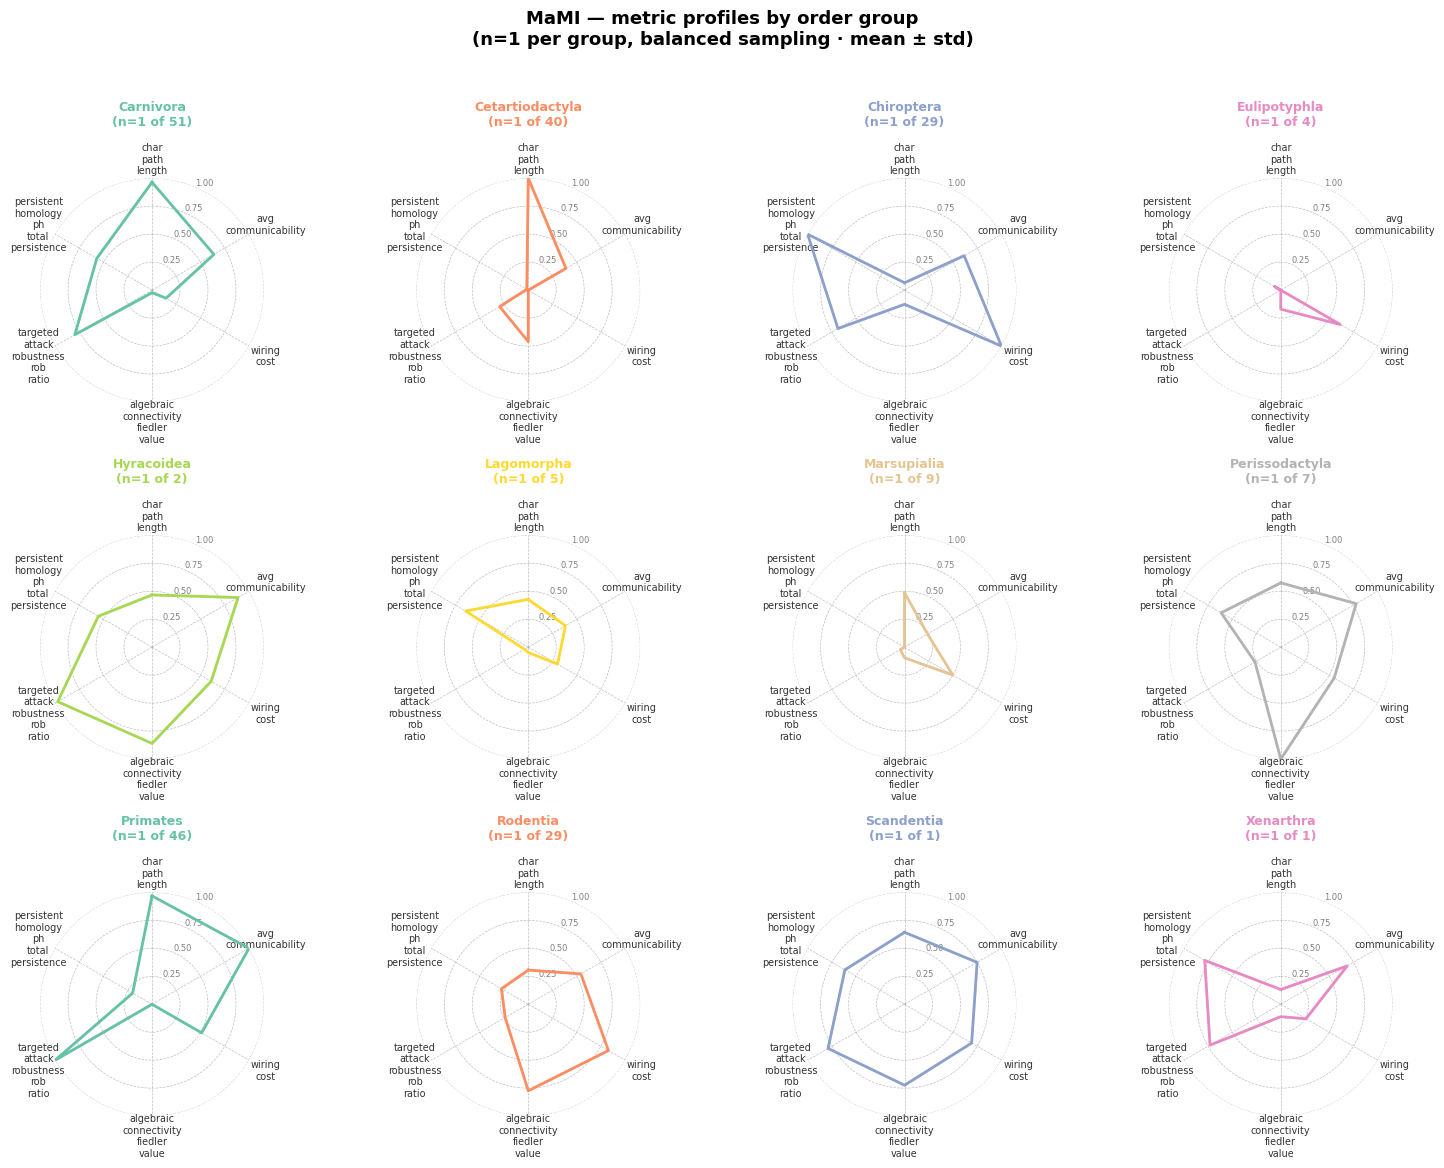

In [ ]:
# ── 1. Merge taxonomy with metric data ────────────────────────────────────────
mami_metrics = dict_with_all_datasets['suarez_MaMI_dataset'][SELECTED_COLS].reset_index(drop=True)
info_mami    = info_mami.reset_index(drop=True)
what_to_look_at = "order"



# Safety check
assert len(mami_metrics) == len(info_mami), \
    f"Row mismatch: metrics={len(mami_metrics)}, taxonomy={len(info_mami)}"

mami_full = pd.concat([info_mami[['animal', 'common_name', what_to_look_at]], 
                        mami_metrics], axis=1)

# ── 2. Find minimum group size → sample that many per group ──────────────────
group_counts = mami_full.groupby(what_to_look_at).size()
print(f"Animals per {what_to_look_at} group:")
print(group_counts.sort_values())
print(f"\n→ Minimum group size: {group_counts.min()} ({group_counts.idxmin()})")

N_PER_GROUP = group_counts.min()

sampled = (
    mami_full
    .groupby(what_to_look_at, group_keys=False)
    .apply(lambda g: g.sample(n=N_PER_GROUP, random_state=SEED))
    .reset_index(drop=True)
)

# ── 3. Compute per-group mean & std ───────────────────────────────────────────
group_stats = {}
for group, gdf in sampled.groupby(what_to_look_at):
    vals = gdf[SELECTED_COLS]
    group_stats[group] = (vals.mean(), vals.std(ddof=0).fillna(0))

# ── 4. Normalise — using the global col_min/col_range from before,
#       OR recompute fresh from MaMI only (pick one) ─────────────────────────
# Fresh normalisation across MaMI groups only:
all_group_means = pd.DataFrame({k: v[0] for k, v in group_stats.items()}).T
g_min   = all_group_means.min()
g_max   = all_group_means.max()
g_range = (g_max - g_min).replace(0, 1)

def normalise_mami(series):
    return (series - g_min) / g_range

# ── 5. Plot ───────────────────────────────────────────────────────────────────
n_groups = len(group_stats)
PALETTE  = plt.cm.Set2.colors

ncols = min(4, n_groups)
nrows = int(np.ceil(n_groups / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 3.8, nrows * 3.8),
    subplot_kw=dict(polar=True)
)
axes_flat = np.array(axes).flatten()

for idx, (group, (mean_raw, std_raw)) in enumerate(sorted(group_stats.items())):
    mean_n  = normalise_mami(mean_raw).values
    std_n   = (std_raw / g_range).values
    color   = PALETTE[idx % len(PALETTE)]
    n_shown = group_counts[group]   # original count for subtitle

    make_spider(
        ax     = axes_flat[idx],
        values = mean_n,
        errors = std_n,
        labels = SELECTED_COLS,
        color  = color,
        title  = f"{group}\n(n={N_PER_GROUP} of {n_shown})",
    )

for ax in axes_flat[n_groups:]:
    ax.set_visible(False)

fig.suptitle(
    f'MaMI — metric profiles by {what_to_look_at} group\n'
    f'(n={N_PER_GROUP} per group, balanced sampling · mean ± std)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('spider_mami_order.png', dpi=150, bbox_inches='tight')
plt.show()

['Primates',
 'Rodentia',
 'Hyracoidea',
 'Carnivora',
 'Perissodactyla',
 'Chiroptera',
 'Cetartiodactyla',
 'Eulipotyphla',
 'Scandentia',
 'Xenarthra',
 'Lagomorpha',
 'Marsupialia']

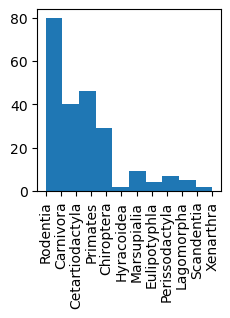

In [ ]:
plt.figure(figsize=viz.cm_to_inch((6,6)))
plt.hist(info_mami["order"]) 
plt.xticks(rotation=90)
list(set(info_mami["order"]))

✓ Keeping 4 group(s): ['Carnivora', 'Cetartiodactyla', 'Primates', 'Rodentia']

Animals per 'order':
order
Rodentia           29
Cetartiodactyla    40
Primates           46
Carnivora          51

→ Minimum group size: 29 (Rodentia)


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_98942/2962466732.py:58: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=N_PER_GROUP, random_state=SEED))


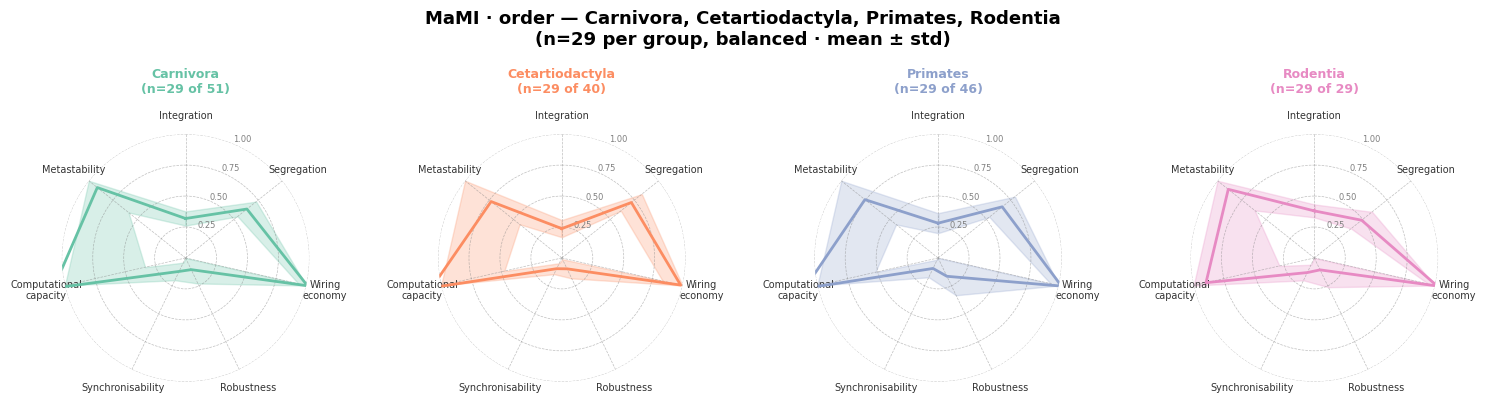

Saved → spider_mami_order.png


In [ ]:
# ── 0. Configuration ──────────────────────────────────────────────────────────
what_to_look_at   = "order"
GROUPS_TO_INCLUDE = [
                    'Primates',
                    'Rodentia',
                    # 'Hyracoidea',
                    'Carnivora',
                    # 'Perissodactyla',
                    # 'Chiroptera',
                    'Cetartiodactyla',
                    # 'Eulipotyphla',
                    # 'Scandentia',
                    # 'Xenarthra',
                    # 'Lagomorpha',
                    # 'Marsupialia'
                ]

# None to include ALL groups # list(set(info_mami["order"])) #

# ── 1. Merge taxonomy with metric data ────────────────────────────────────────
mami_metrics = dict_with_all_datasets['suarez_MaMI_dataset'][SELECTED_COLS].reset_index(drop=True)
info_mami    = info_mami.reset_index(drop=True)

assert len(mami_metrics) == len(info_mami), \
    f"Row mismatch: metrics={len(mami_metrics)}, taxonomy={len(info_mami)}"

mami_full = pd.concat(
    [info_mami[['animal', 'common_name', what_to_look_at]], mami_metrics], axis=1
)

# ── 1b. Optional group filter ─────────────────────────────────────────────────
if GROUPS_TO_INCLUDE is not None:
    # Case-insensitive matching so "rodentia" == "Rodentia"
    available = mami_full[what_to_look_at].unique()
    matched   = [g for g in available
                 if g.lower() in [x.lower() for x in GROUPS_TO_INCLUDE]]
    not_found = [x for x in GROUPS_TO_INCLUDE
                 if x.lower() not in [g.lower() for g in available]]

    if not_found:
        print(f"⚠ The following groups were not found in '{what_to_look_at}' "
              f"and will be ignored: {not_found}")
    print(f"✓ Keeping {len(matched)} group(s): {sorted(matched)}")

    mami_full = mami_full[mami_full[what_to_look_at].isin(matched)].reset_index(drop=True)

# ── 2. Find minimum group size → sample that many per group ──────────────────
group_counts = mami_full.groupby(what_to_look_at).size()
print(f"\nAnimals per '{what_to_look_at}':")
print(group_counts.sort_values().to_string())
print(f"\n→ Minimum group size: {group_counts.min()} ({group_counts.idxmin()})")

N_PER_GROUP = group_counts.min()

sampled = (
    mami_full
    .groupby(what_to_look_at, group_keys=False)
    .apply(lambda g: g.sample(n=N_PER_GROUP, random_state=SEED))
    .reset_index(drop=True)
)

# ── 3. Compute per-group mean & std ───────────────────────────────────────────
group_stats = {}
for group, gdf in sampled.groupby(what_to_look_at):
    vals = gdf[SELECTED_COLS]
    group_stats[group] = (vals.mean(), vals.std(ddof=0).fillna(0))

# ── 4. Normalise across selected groups only ──────────────────────────────────
all_group_means = pd.DataFrame({k: v[0] for k, v in group_stats.items()}).T
g_min   = all_group_means.min()
g_max   = all_group_means.max()
g_range = (g_max - g_min).replace(0, 1)

g_range = COL_RANGE
# def normalise_mami(series):
#     return (series - g_min) / COL_RANGE #  g_range

# ── 5. Plot ───────────────────────────────────────────────────────────────────
n_groups  = len(group_stats)
PALETTE   = plt.cm.Set2.colors

ncols = min(4, n_groups)
nrows = int(np.ceil(n_groups / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 3.8, nrows * 3.8),
    subplot_kw=dict(polar=True)
)
axes_flat = np.array(axes).flatten()

for idx, (group, (mean_raw, std_raw)) in enumerate(sorted(group_stats.items())):
    # mean_n = normalise_mami(mean_raw).values
    mean_n = normalise(mean_raw).values
    std_n  = (std_raw / g_range).values
    color  = PALETTE[idx % len(PALETTE)]

    make_spider(
        ax     = axes_flat[idx],
        values = mean_n,
        errors = std_n,
        labels = selected_properties.keys(), # SELECTED_COLS,
        color  = color,
        title  = f"{group}\n(n={N_PER_GROUP} of {group_counts[group]})",
    )

for ax in axes_flat[n_groups:]:
    ax.set_visible(False)

group_label = "all groups" if GROUPS_TO_INCLUDE is None else ", ".join(sorted(matched))
fig.suptitle(
    f'MaMI · {what_to_look_at} — {group_label}\n'
    f'(n={N_PER_GROUP} per group, balanced · mean ± std)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()

fname = f"spider_mami_{what_to_look_at}.png"
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {fname}")

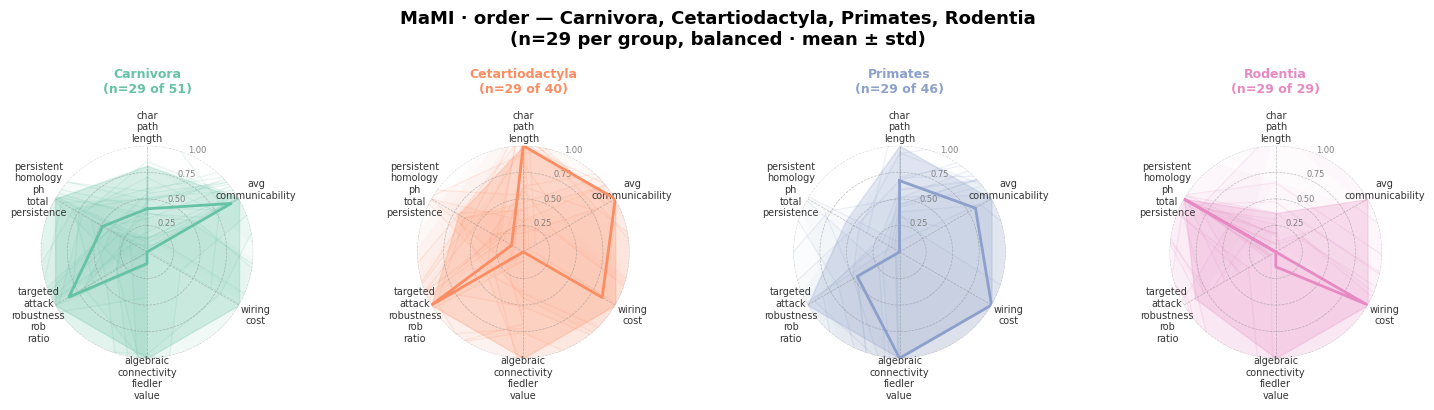

Saved → spider_mami_order.png


In [ ]:
# ── 5. Plot ───────────────────────────────────────────────────────────────────
n_groups  = len(group_stats)
PALETTE   = plt.cm.Set2.colors

ncols = min(4, n_groups)
nrows = int(np.ceil(n_groups / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 3.8, nrows * 3.8),
    subplot_kw=dict(polar=True)
)
axes_flat = np.array(axes).flatten()

for idx, (group, (mean_raw, std_raw)) in enumerate(sorted(group_stats.items())):
    mean_n = normalise_mami(mean_raw).values
    std_n  = (std_raw / g_range).values
    color  = PALETTE[idx % len(PALETTE)]
    ax     = axes_flat[idx]

    # ── Individual animal contours (low alpha) ────────────────────────────
    group_df = sampled[sampled[what_to_look_at] == group][SELECTED_COLS]
    n_cols   = len(SELECTED_COLS)
    angles   = np.linspace(0, 2 * np.pi, n_cols, endpoint=False).tolist()
    angles  += angles[:1]  # close the polygon

    for _, row in group_df.iterrows():
        ind_n  = normalise_mami(row).values.tolist()
        ind_n += ind_n[:1]  # close the polygon
        ax.plot(angles, ind_n, color=color, alpha=0.12, linewidth=0.8)
        ax.fill(angles, ind_n, color=color, alpha=0.03)

    # ── Group mean contour (drawn on top) ─────────────────────────────────
    make_spider(
        ax     = ax,
        values = mean_n,
        errors = std_n,
        labels = SELECTED_COLS,
        color  = color,
        title  = f"{group}\n(n={N_PER_GROUP} of {group_counts[group]})",
    )

for ax in axes_flat[n_groups:]:
    ax.set_visible(False)

group_label = "all groups" if GROUPS_TO_INCLUDE is None else ", ".join(sorted(matched))
fig.suptitle(
    f'MaMI · {what_to_look_at} — {group_label}\n'
    f'(n={N_PER_GROUP} per group, balanced · mean ± std)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()

fname = f"spider_mami_{what_to_look_at}.png"
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {fname}")

In [ ]:
df_gnm_g = dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].groupby(["eta", "gamma"]).mean().reset_index()

# EXCLUDE COLUMNS: 
constant_columns = ["avg_degree", "n_connected_components", "density", "density_bct", "kernel_rank_phase_of_lambda_max"]
df_gnm_g = df_gnm_g.drop(columns=[col for col in constant_columns if col in df_gnm_g.columns])

cols_of_interest = [col for col in df_gnm_g.columns if col not in ["eta", "gamma"]]
len(cols_of_interest)

164

In [ ]:
dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"]

,eta,gamma,energy,avg_communicability,avg_edge_distance,wiring_cost,char_path_length,richclub_n_edges,richclub_avg_length,mc_mean,...,persistent_homology_ph_total_persistence,targeted_attack_robustness_rob_targeted_auc,targeted_attack_robustness_rob_random_auc,targeted_attack_robustness_rob_ratio,targeted_attack_robustness_rob_targeted_half,targeted_attack_robustness_rob_random_half,algebraic_connectivity_fiedler_value,algebraic_connectivity_fiedler_value_norm,algebraic_connectivity_laplacian_spectral_gap,algebraic_connectivity_fiedler_bipartition_balance
0,1.204082,0.304082,0.320000,0.011247,76.077667,37658.445312,2.689091,91.0,81.162041,8.142928,...,104.0,0.3978,0.46037,0.864088,0.44,0.462,0.228483,0.008238,0.689275,0.16
1,-4.857143,0.663265,0.880000,0.014904,63.799976,31580.988281,2.251111,47.0,55.601665,8.059048,...,198.0,0.4446,0.48827,0.910562,0.48,0.500,2.884382,0.133069,0.946072,0.78
2,-5.979592,0.124490,0.940000,0.015729,70.102951,34700.960938,2.230505,36.0,71.146706,8.449266,...,228.5,0.4557,0.48724,0.935268,0.49,0.498,2.883610,0.146973,0.906313,0.56
3,0.530612,0.146939,0.670000,0.013722,69.063416,34186.390625,2.315758,60.0,79.657097,8.598514,...,135.5,0.4182,0.48623,0.860087,0.49,0.493,1.511857,0.061605,0.901723,0.26
4,-3.959184,0.932653,0.438384,0.012760,45.163860,22356.111328,2.409091,64.0,32.699265,8.795462,...,137.5,0.4322,0.48371,0.893511,0.48,0.497,1.735451,0.073960,0.859572,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,-3.285714,-0.032653,0.750000,0.014865,41.555737,20570.089844,2.383232,50.0,32.892582,8.875647,...,168.5,0.4663,0.48473,0.961979,0.50,0.498,1.837761,0.091905,0.791142,0.92
24996,-6.428571,0.887755,0.940000,0.015477,69.142136,34225.355469,2.234747,37.0,76.618568,8.554603,...,217.0,0.4510,0.48442,0.931010,0.49,0.500,1.827213,0.090019,0.549150,0.26
24997,-1.265306,0.685714,0.560000,0.012226,37.178089,18403.154297,4.437778,54.0,34.170551,8.429982,...,99.0,0.3705,0.36101,1.026287,0.43,0.297,0.042775,0.002047,0.474272,0.40
24998,-2.163265,0.842857,0.563636,0.011641,35.095871,17372.457031,4.465657,82.0,27.948391,8.254480,...,99.0,0.3579,0.42099,0.850139,0.30,0.435,0.099793,0.004809,0.633401,0.50


## Now adding DeltaCon (or similar)

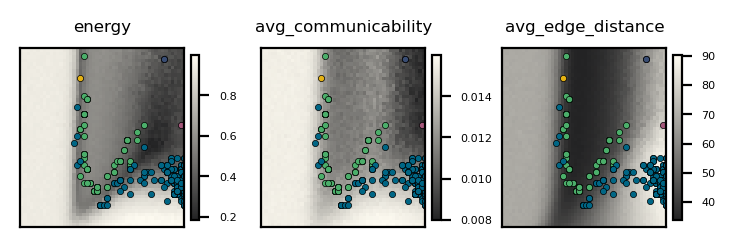

In [ ]:
# Get the metric values at these minimum locations for coloring
# We'll use the same metric as shown in each subplot
# df_gnm_with_coords = dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].copy()

n_cols = 8
n_rows = (len(cols_of_interest) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=viz.cm_to_inch((n_cols * 3, n_rows * 2.5)), sharex=True, sharey=True, dpi=200)

for idx, col in enumerate(cols_of_interest):
    row = idx // n_cols
    col_idx = idx % n_cols
    ax = axes[row, col_idx]
    
    # Create the heatmap
    pivot_data = df_gnm_g.pivot(index="gamma", columns="eta", values=col)

    # Get the actual data ranges (STEP 1 TO COMBINE SCATTER AND IMSHOW)
    x_min, x_max = pivot_data.columns.min(), pivot_data.columns.max()
    y_min, y_max = pivot_data.index.min(), pivot_data.index.max()

    im = ax.imshow(pivot_data, 
                   extent=[x_min, x_max, y_min, y_max], # STEP 2 TO COMBINE SCATTER AND IMSHOW
                   aspect="auto", origin="lower", cmap=gray_cmap.reversed()) # "viridis")

    # Plot individual points
    for dataset in dict_with_all_datasets.keys():

        # Skip the gnm dataset, as it will now have two eta and gamma columns. 
        if dataset == "hcp_schaefer_100_dataset_gnm":
            continue

        df_merged = dict_with_all_datasets[dataset]
        if col in df_merged.columns:
            ax.scatter(df_merged["eta"], df_merged['gamma'],
                #    c=df_merged[col],
                       c=COLOR_SCHEME[dataset],
                       edgecolor="black",
                       label=dataset,
                       linewidth=0.25, s=5)

    # if the title is too long (define this), then split it into two lines at the last underscore
    if len(col) > 20:
        col = re.split(r'[,,_]+', col)
        len_col = len(col)
        col = "_".join(col[:len_col//2]) + "\n" + "_".join(col[len_col//2:])
    ax.set_title(col, fontsize=6)
    
    ax.set_xticks([])
    ax.set_yticks([])
    
    # ax.legend(fontsize=3, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=4) 
    
    if idx >= 2: 
        break

# remove empty subplots
for idx in range(idx+1, n_rows * n_cols):
    row = idx // n_cols
    col_idx = idx % n_cols
    fig.delaxes(axes[row, col_idx])
    
plt.tight_layout(pad=0.4)

# plt.savefig(output_folder / "gnm_property_heatmaps_with_deltacon_minimums.pdf", dpi=200)

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_89133/763494191.py:53: UserWarning: Adding colorbar to a different Figure <Figure size 1889.76x4133.86 with 7 Axes> than <Figure size 314.961x236.22 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_89133/763494191.py:56: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=0.4)


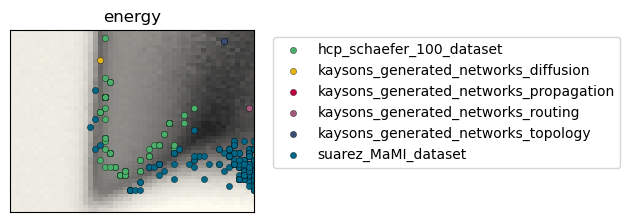

In [ ]:
# Get the metric values at these minimum locations for coloring
# We'll use the same metric as shown in each subplot
# df_gnm_with_coords = dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].copy()

# n_cols = 8
# n_rows = (len(cols_of_interest) + n_cols - 1) // n_cols
# fig, axes = plt.subplots(n_rows, n_cols, figsize=viz.cm_to_inch((n_cols * 3, n_rows * 2.5)), sharex=True, sharey=True, dpi=200)
col = cols_of_interest[0] # energy


plt.figure(figsize=viz.cm_to_inch((8,6)))
# for idx, col in enumerate(cols_of_interest):

# Create the heatmap
pivot_data = df_gnm_g.pivot(index="gamma", columns="eta", values=col)

# Get the actual data ranges (STEP 1 TO COMBINE SCATTER AND IMSHOW)
x_min, x_max = pivot_data.columns.min(), pivot_data.columns.max()
y_min, y_max = pivot_data.index.min(), pivot_data.index.max()

plt.imshow(pivot_data, 
                extent=[x_min, x_max, y_min, y_max], # STEP 2 TO COMBINE SCATTER AND IMSHOW
                aspect="auto", origin="lower", cmap=gray_cmap.reversed()) # "viridis")

# Plot individual points
for dataset in dict_with_all_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]
    if col in df_merged.columns:
        plt.scatter(df_merged["eta"], df_merged['gamma'],
            #    c=df_merged[col],
                    c=COLOR_SCHEME[dataset],
                    edgecolor="black",
                    label=dataset,
                    linewidth=0.25, s=20)

# if the title is too long (define this), then split it into two lines at the last underscore
if len(col) > 20:
    col = re.split(r'[,,_]+', col)
    len_col = len(col)
    col = "_".join(col[:len_col//2]) + "\n" + "_".join(col[len_col//2:])
plt.title(col) #  fontsize=6)

plt.xticks([])
plt.yticks([])

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=4) 
    
plt.tight_layout(pad=0.4)

# plt.savefig(output_folder / "gnm_property_heatmaps_with_deltacon_minimums.pdf", dpi=200)

In [ ]:

# drop row 95
dict_with_all_datasets["suarez_MaMI_dataset"] = dict_with_all_datasets["suarez_MaMI_dataset"].drop(index=95)

dict_with_all_datasets["suarez_MaMI_dataset"]

,energy,eta,gamma,id,omega,directed_simplices_count,directed_simplices_max_size,wiring_cost,avg_clustering,degree_assortativity,...,algebraic_connectivity_fiedler_bipartition_balance,persistent_homology_ph_h0_n_features,persistent_homology_ph_h0_persistence_mean,persistent_homology_ph_h0_persistence_std,persistent_homology_ph_h0_entropy,persistent_homology_ph_h1_n_features,persistent_homology_ph_h1_persistence_mean,persistent_homology_ph_h1_persistence_std,persistent_homology_ph_h1_entropy,persistent_homology_ph_total_persistence
0,0.20,2.102041,0.191837,5,0.607249,334.0,5.0,6.885055,0.242105,-0.139680,...,0.20,99.0,1.0,0.0,4.59512,63.0,0.5,0.0,4.143135,130.5
1,0.17,3.000000,0.169388,8,0.583831,319.0,5.0,6.830447,0.243338,0.036338,...,0.14,99.0,1.0,0.0,4.59512,90.0,0.5,0.0,4.499810,144.0
2,0.17,2.551020,0.191837,4,0.501974,297.0,6.0,6.722624,0.290707,-0.098389,...,0.88,99.0,1.0,0.0,4.59512,64.0,0.5,0.0,4.158883,131.0
3,0.16,3.000000,0.281633,4,0.469093,308.0,5.0,6.723156,0.309964,-0.026754,...,0.98,99.0,1.0,0.0,4.59512,53.0,0.5,0.0,3.970292,125.5
4,0.16,2.326531,0.191837,0,0.485175,321.0,5.0,6.338058,0.274466,0.007061,...,1.00,99.0,1.0,0.0,4.59512,64.0,0.5,0.0,4.158883,131.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,0.17,2.775510,0.146939,5,0.489480,271.0,5.0,7.282549,0.300607,-0.038329,...,0.96,99.0,1.0,0.0,4.59512,59.0,0.5,0.0,4.077537,128.5
221,0.16,2.551020,0.124490,0,0.525896,316.0,6.0,7.301747,0.291301,-0.040741,...,0.86,99.0,1.0,0.0,4.59512,65.0,0.5,0.0,4.174387,131.5
222,0.24,1.653061,0.146939,0,0.583410,285.0,6.0,7.416419,0.244901,0.034593,...,0.38,99.0,1.0,0.0,4.59512,89.0,0.5,0.0,4.488636,143.5
223,0.16,2.775510,0.169388,1,0.593756,306.0,6.0,7.489097,0.247813,0.022037,...,0.56,99.0,1.0,0.0,4.59512,105.0,0.5,0.0,4.653960,151.5


,Unnamed: 0,animal,common_name,name,species,genus,sub_family,family,sub_order,order,super_order,phylogenetic_group,brain_weight_g,brain_volume_cm3,brain_data_source
0,0,Rat4,Fat sand rat,Rat,Rattus norvegicus,Rattus,Murinae,Muridae,Myomorpha,Rodentia,Euarchontoglires,Euarchontoglires,2.0,1.93,Literature
1,1,Mouse,Mouse,Mouse,Mus musculus,Mus,Murinae,Muridae,Myomorpha,Rodentia,Euarchontoglires,Euarchontoglires,0.4,0.39,Literature
2,2,Meerkat4,Meerkat,Meerkat,Suricata suricata,Suricata,Mungotinae,Herpestidae,Feliformia,Carnivora,Laurasiatheria,Laurasiatheria,10.3,9.94,Literature
3,3,CapraNubiana3,Nubian ibex,Capra Nubiana,Capra Nubiana,Capra,Caprinae,Bovidae,Ruminantia,Cetartiodactyla,Laurasiatheria,Laurasiatheria,NaN,NaN,NaN
4,4,Oryx1,Oryx,Oryx,Oryx leucoryx,Oryx,Hippotranginae,Bovidae,Ruminantia,Cetartiodactyla,Laurasiatheria,Laurasiatheria,275.0,265.40,Literature
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,220,LemurCatta1,Ring tailed lemur,Lemur Catta,Lemur catta,Lemur,Lemur,Lemuridae,Strepsirrhini,Primates,Euarchontoglires,Euarchontoglires,24.5,23.60,Literature
220,221,FruitBat2,Egyptian fruit bat,Fruit Bat,Rousettus aegyptiacus,Rousettus,Pteropodinae,Pteropodidae,Megachiroptera,Chiroptera,Laurasiatheria,Laurasiatheria,3.4,3.28,Literature
221,222,Baboon4,Hemadryas baboon,Baboon,Papio hamadryas (Baboon),Papio,Cercopithecinae,Cercopithecidae,Haplorrhini,Primates,Euarchontoglires,Euarchontoglires,NaN,NaN,NaN
222,223,Agouti2,Red-rumped agouti,Agouti,Dasyprocta leporina,Dasyprocta,Dasyprocta,Dasyproctidae,Hystricomorpha,Rodentia,Euarchontoglires,Euarchontoglires,13.7,13.22,Literature


In [ ]:
# join dict_with_all_datasets["suarez_MaMI_dataset"] and info_mami by index 
df_merged_mami = pd.merge(dict_with_all_datasets["suarez_MaMI_dataset"], info_mami, left_index=True, right_index=True)
df_merged_mami

,energy,eta,gamma,id,omega,directed_simplices_count,directed_simplices_max_size,wiring_cost,avg_clustering,degree_assortativity,...,genus,sub_family,family,sub_order,order,super_order,phylogenetic_group,brain_weight_g,brain_volume_cm3,brain_data_source
0,0.20,2.102041,0.191837,5,0.607249,334.0,5.0,6.885055,0.242105,-0.139680,...,Rattus,Murinae,Muridae,Myomorpha,Rodentia,Euarchontoglires,Euarchontoglires,2.0,1.93,Literature
1,0.17,3.000000,0.169388,8,0.583831,319.0,5.0,6.830447,0.243338,0.036338,...,Mus,Murinae,Muridae,Myomorpha,Rodentia,Euarchontoglires,Euarchontoglires,0.4,0.39,Literature
2,0.17,2.551020,0.191837,4,0.501974,297.0,6.0,6.722624,0.290707,-0.098389,...,Suricata,Mungotinae,Herpestidae,Feliformia,Carnivora,Laurasiatheria,Laurasiatheria,10.3,9.94,Literature
3,0.16,3.000000,0.281633,4,0.469093,308.0,5.0,6.723156,0.309964,-0.026754,...,Capra,Caprinae,Bovidae,Ruminantia,Cetartiodactyla,Laurasiatheria,Laurasiatheria,NaN,NaN,NaN
4,0.16,2.326531,0.191837,0,0.485175,321.0,5.0,6.338058,0.274466,0.007061,...,Oryx,Hippotranginae,Bovidae,Ruminantia,Cetartiodactyla,Laurasiatheria,Laurasiatheria,275.0,265.40,Literature
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,0.17,3.000000,0.281633,4,0.503614,300.0,6.0,8.473967,0.303534,0.036105,...,Lemur,Lemur,Lemuridae,Strepsirrhini,Primates,Euarchontoglires,Euarchontoglires,24.5,23.60,Literature
220,0.17,2.775510,0.146939,5,0.489480,271.0,5.0,7.282549,0.300607,-0.038329,...,Rousettus,Pteropodinae,Pteropodidae,Megachiroptera,Chiroptera,Laurasiatheria,Laurasiatheria,3.4,3.28,Literature
221,0.16,2.551020,0.124490,0,0.525896,316.0,6.0,7.301747,0.291301,-0.040741,...,Papio,Cercopithecinae,Cercopithecidae,Haplorrhini,Primates,Euarchontoglires,Euarchontoglires,NaN,NaN,NaN
222,0.24,1.653061,0.146939,0,0.583410,285.0,6.0,7.416419,0.244901,0.034593,...,Dasyprocta,Dasyprocta,Dasyproctidae,Hystricomorpha,Rodentia,Euarchontoglires,Euarchontoglires,13.7,13.22,Literature


In [ ]:
# df_merged_mami["order"] to color the points in the scatter plot. But: Order entries are strings rn...
df_merged_mami["order_color"] = df_merged_mami["order"].astype("category").cat.codes
df_merged_mami["phylogenetic_group_color"] = df_merged_mami["phylogenetic_group"].astype("category").cat.codes
df_merged_mami[["order_color", "phylogenetic_group_color"]]


,order_color,phylogenetic_group_color
0,9,0
1,9,0
2,0,1
3,1,1
4,1,1
...,...,...
219,8,0
220,2,1
221,8,0
222,9,0


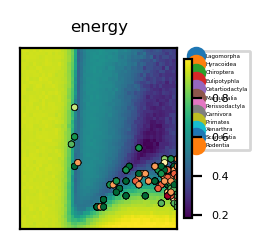

In [ ]:
# Get the metric values at these minimum locations for coloring
# We'll use the same metric as shown in each subplot
# df_gnm_with_coords = dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].copy()

n_cols = 8
n_rows = (len(cols_of_interest) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=viz.cm_to_inch((n_cols * 3, n_rows * 2.5)), sharex=True, sharey=True, dpi=200)

for idx, col in enumerate(cols_of_interest):
    row = idx // n_cols
    col_idx = idx % n_cols
    ax = axes[row, col_idx]
    
    # Create the heatmap
    pivot_data = df_gnm_g.pivot(index="gamma", columns="eta", values=col)

    # Get the actual data ranges (STEP 1 TO COMBINE SCATTER AND IMSHOW)
    x_min, x_max = pivot_data.columns.min(), pivot_data.columns.max()
    y_min, y_max = pivot_data.index.min(), pivot_data.index.max()

    im = ax.imshow(pivot_data, 
                   extent=[x_min, x_max, y_min, y_max], # STEP 2 TO COMBINE SCATTER AND IMSHOW
                   aspect="auto", origin="lower", cmap="viridis")
    
    # Plot individual points
    for dataset in dict_with_all_datasets.keys():

        # Skip the gnm dataset, as it will now have two eta and gamma columns. 
        if dataset == "hcp_schaefer_100_dataset_gnm":
            continue

        # df_merged = dict_with_all_datasets[dataset]
        # if col in df_merged.columns:
        #     ax.scatter(df_merged["eta"], df_merged['gamma'],
        #                c=df_merged[col],
        #                edgecolor="black",
        #                linewidth=0.25, s=5)
        
        ax.scatter(df_merged_mami["eta"], df_merged_mami['gamma'],
            c=df_merged_mami["order_color"],
            # label=df_merged_mami["order"],
            edgecolor="black",
            linewidth=0.25, s=5, cmap="RdYlGn_r")

    # if the title is too long (define this), then split it into two lines at the last underscore
    if len(col) > 20:
        col = re.split(r'[,,_]+', col)
        len_col = len(col)
        col = "_".join(col[:len_col//2]) + "\n" + "_".join(col[len_col//2:])
    ax.set_title(col, fontsize=6)
    
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Make legend with "order_color" colors and "order" labels
    # handles, labels = ax.get_legend_handles_labels()
    # by_label = dict(zip(list(set(labels)), list(set(handles))))
    # ax.legend(by_label.values(), by_label.keys(), title="Order", fontsize=2, title_fontsize=2, loc="upper right", markerscale=2) # , bbox_to_anchor=(1.2, 1))
    
        
    # Here we create a legend: # TODO: FIX???
    # we'll plot empty lists with the desired size and label
    for color, name in zip(list(set(df_merged_mami["order_color"])), list(set(df_merged_mami["order"]))):
        ax.scatter([], [], # c=color, # alpha=0.3 # , s=unique_scatters[0],
                    label=str(name))
    ax.legend(fontsize=2, bbox_to_anchor=(1.05, 1), loc='upper left') # , frameon=False, labelspacing=1, title='City Area') phylogenetic_group

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=4) 
    
    break
    
    # if idx >= 2: 
    #     break
    


# remove empty subplots
for idx in range(idx+1, n_rows * n_cols):
    row = idx // n_cols
    col_idx = idx % n_cols
    fig.delaxes(axes[row, col_idx])
    
# title="Order") # , fontsize=6, title_fontsize=8, loc="upper right", markerscale=2) # , bbox_to_anchor=(1.2, 1))

plt.tight_layout(pad=0.4)

# plt.savefig(output_folder / "gnm_property_heatmaps_with_deltacon_minimums.pdf", dpi=200)

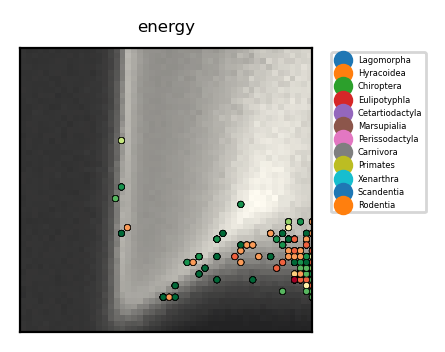

In [ ]:
# Get the metric values at these minimum locations for coloring
# We'll use the same metric as shown in each subplot
# df_gnm_with_coords = dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].copy()

n_cols = 2
n_rows = (len(cols_of_interest) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=viz.cm_to_inch((n_cols * 5, n_rows * 4)), sharex=True, sharey=True, dpi=200)

for idx, col in enumerate(cols_of_interest):
    row = idx // n_cols
    col_idx = idx % n_cols
    ax = axes[row, col_idx]
    
    # Create the heatmap
    pivot_data = df_gnm_g.pivot(index="gamma", columns="eta", values=col)

    # Get the actual data ranges (STEP 1 TO COMBINE SCATTER AND IMSHOW)
    x_min, x_max = pivot_data.columns.min(), pivot_data.columns.max()
    y_min, y_max = pivot_data.index.min(), pivot_data.index.max()

    im = ax.imshow(pivot_data, 
                   extent=[x_min, x_max, y_min, y_max], # STEP 2 TO COMBINE SCATTER AND IMSHOW
                   aspect="auto", origin="lower", cmap=gray_cmap) # "viridis")
    
    # Plot individual points
    for dataset in dict_with_all_datasets.keys():

        # Skip the gnm dataset, as it will now have two eta and gamma columns. 
        if dataset == "hcp_schaefer_100_dataset_gnm":
            continue

        # df_merged = dict_with_all_datasets[dataset]
        # if col in df_merged.columns:
        #     ax.scatter(df_merged["eta"], df_merged['gamma'],
        #                c=df_merged[col],
        #                edgecolor="black",
        #                linewidth=0.25, s=5)
        
        ax.scatter(df_merged_mami["eta"], df_merged_mami['gamma'],
            c=df_merged_mami["order_color"],
            # label=df_merged_mami["order"],
            edgecolor="black",
            linewidth=0.25, s=5, cmap="RdYlGn_r")

    # if the title is too long (define this), then split it into two lines at the last underscore
    if len(col) > 20:
        col = re.split(r'[,,_]+', col)
        len_col = len(col)
        col = "_".join(col[:len_col//2]) + "\n" + "_".join(col[len_col//2:])
    ax.set_title(col, fontsize=6)
    
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Make legend with "order_color" colors and "order" labels
    # handles, labels = ax.get_legend_handles_labels()
    # by_label = dict(zip(list(set(labels)), list(set(handles))))
    # ax.legend(by_label.values(), by_label.keys(), title="Order", fontsize=2, title_fontsize=2, loc="upper right", markerscale=2) # , bbox_to_anchor=(1.2, 1))
    
        
    # Here we create a legend: # TODO: FIX???
    # we'll plot empty lists with the desired size and label
    for color, name in zip(list(set(df_merged_mami["order_color"])), list(set(df_merged_mami["order"]))):
        ax.scatter([], [], # c=color, # alpha=0.3 # , s=unique_scatters[0],
                    label=str(name))
    ax.legend(fontsize=3, bbox_to_anchor=(1.05, 1), loc='upper left') # , frameon=False, labelspacing=1, title='City Area') phylogenetic_group

    # cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    # cbar.ax.tick_params(labelsize=4) 
    
    break
    
    # if idx >= 2: 
    #     break
    


# remove empty subplots
for idx in range(idx+1, n_rows * n_cols):
    row = idx // n_cols
    col_idx = idx % n_cols
    fig.delaxes(axes[row, col_idx])
    
# title="Order") # , fontsize=6, title_fontsize=8, loc="upper right", markerscale=2) # , bbox_to_anchor=(1.2, 1))

plt.tight_layout() # pad=0.4)

# plt.savefig(output_folder / "gnm_property_heatmaps_with_deltacon_minimums.pdf", dpi=200)

In [ ]:
df_merged_mami

,energy,eta,gamma,id,omega,directed_simplices_count,directed_simplices_max_size,wiring_cost,avg_clustering,degree_assortativity,...,family,sub_order,order,super_order,phylogenetic_group,brain_weight_g,brain_volume_cm3,brain_data_source,order_color,phylogenetic_group_color
0,0.20,2.102041,0.191837,5,0.607249,334.0,5.0,6.885055,0.242105,-0.139680,...,Muridae,Myomorpha,Rodentia,Euarchontoglires,Euarchontoglires,2.0,1.93,Literature,9,0
1,0.17,3.000000,0.169388,8,0.583831,319.0,5.0,6.830447,0.243338,0.036338,...,Muridae,Myomorpha,Rodentia,Euarchontoglires,Euarchontoglires,0.4,0.39,Literature,9,0
2,0.17,2.551020,0.191837,4,0.501974,297.0,6.0,6.722624,0.290707,-0.098389,...,Herpestidae,Feliformia,Carnivora,Laurasiatheria,Laurasiatheria,10.3,9.94,Literature,0,1
3,0.16,3.000000,0.281633,4,0.469093,308.0,5.0,6.723156,0.309964,-0.026754,...,Bovidae,Ruminantia,Cetartiodactyla,Laurasiatheria,Laurasiatheria,NaN,NaN,NaN,1,1
4,0.16,2.326531,0.191837,0,0.485175,321.0,5.0,6.338058,0.274466,0.007061,...,Bovidae,Ruminantia,Cetartiodactyla,Laurasiatheria,Laurasiatheria,275.0,265.40,Literature,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,0.17,3.000000,0.281633,4,0.503614,300.0,6.0,8.473967,0.303534,0.036105,...,Lemuridae,Strepsirrhini,Primates,Euarchontoglires,Euarchontoglires,24.5,23.60,Literature,8,0
220,0.17,2.775510,0.146939,5,0.489480,271.0,5.0,7.282549,0.300607,-0.038329,...,Pteropodidae,Megachiroptera,Chiroptera,Laurasiatheria,Laurasiatheria,3.4,3.28,Literature,2,1
221,0.16,2.551020,0.124490,0,0.525896,316.0,6.0,7.301747,0.291301,-0.040741,...,Cercopithecidae,Haplorrhini,Primates,Euarchontoglires,Euarchontoglires,NaN,NaN,NaN,8,0
222,0.24,1.653061,0.146939,0,0.583410,285.0,6.0,7.416419,0.244901,0.034593,...,Dasyproctidae,Hystricomorpha,Rodentia,Euarchontoglires,Euarchontoglires,13.7,13.22,Literature,9,0


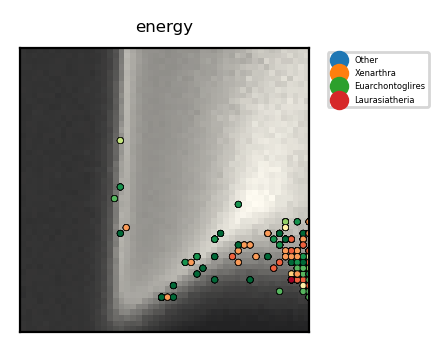

In [ ]:
# Get the metric values at these minimum locations for coloring
# We'll use the same metric as shown in each subplot
# df_gnm_with_coords = dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].copy()

n_cols = 2
n_rows = (len(cols_of_interest) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=viz.cm_to_inch((n_cols * 5, n_rows * 4)), sharex=True, sharey=True, dpi=200)

for idx, col in enumerate(cols_of_interest):
    row = idx // n_cols
    col_idx = idx % n_cols
    ax = axes[row, col_idx]
    
    # Create the heatmap
    pivot_data = df_gnm_g.pivot(index="gamma", columns="eta", values=col)

    # Get the actual data ranges (STEP 1 TO COMBINE SCATTER AND IMSHOW)
    x_min, x_max = pivot_data.columns.min(), pivot_data.columns.max()
    y_min, y_max = pivot_data.index.min(), pivot_data.index.max()

    im = ax.imshow(pivot_data, 
                   extent=[x_min, x_max, y_min, y_max], # STEP 2 TO COMBINE SCATTER AND IMSHOW
                   aspect="auto", origin="lower", cmap=gray_cmap) # "viridis")
    
    # Plot individual points
    for dataset in dict_with_all_datasets.keys():

        # Skip the gnm dataset, as it will now have two eta and gamma columns. 
        if dataset == "hcp_schaefer_100_dataset_gnm":
            continue

        # df_merged = dict_with_all_datasets[dataset]
        # if col in df_merged.columns:
        #     ax.scatter(df_merged["eta"], df_merged['gamma'],
        #                c=df_merged[col],
        #                edgecolor="black",
        #                linewidth=0.25, s=5)
        
        ax.scatter(df_merged_mami["eta"], df_merged_mami['gamma'],
            c=df_merged_mami["order_color"],
            # label=df_merged_mami["order"],
            edgecolor="black",
            linewidth=0.25, s=5, cmap="RdYlGn_r")

    # if the title is too long (define this), then split it into two lines at the last underscore
    if len(col) > 20:
        col = re.split(r'[,,_]+', col)
        len_col = len(col)
        col = "_".join(col[:len_col//2]) + "\n" + "_".join(col[len_col//2:])
    ax.set_title(col, fontsize=6)
    
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Make legend with "order_color" colors and "order" labels
    # handles, labels = ax.get_legend_handles_labels()
    # by_label = dict(zip(list(set(labels)), list(set(handles))))
    # ax.legend(by_label.values(), by_label.keys(), title="Order", fontsize=2, title_fontsize=2, loc="upper right", markerscale=2) # , bbox_to_anchor=(1.2, 1))
    
        
    # Here we create a legend: # TODO: FIX???
    # we'll plot empty lists with the desired size and label
    for color, name in zip(list(set(df_merged_mami["phylogenetic_group_color"])), list(set(df_merged_mami["phylogenetic_group"]))):
        ax.scatter([], [], # c=color, # alpha=0.3 # , s=unique_scatters[0],
                    label=str(name))
    ax.legend(fontsize=3, bbox_to_anchor=(1.05, 1), loc='upper left') # , frameon=False, labelspacing=1, title='City Area') phylogenetic_group

    # cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    # cbar.ax.tick_params(labelsize=4) 
    
    break
    
    # if idx >= 2: 
    #     break
    


# remove empty subplots
for idx in range(idx+1, n_rows * n_cols):
    row = idx // n_cols
    col_idx = idx % n_cols
    fig.delaxes(axes[row, col_idx])
    
# title="Order") # , fontsize=6, title_fontsize=8, loc="upper right", markerscale=2) # , bbox_to_anchor=(1.2, 1))

plt.tight_layout() # pad=0.4)

# plt.savefig(output_folder / "gnm_property_heatmaps_with_deltacon_minimums.pdf", dpi=200)

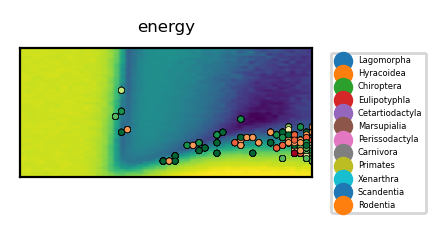

In [ ]:
# Get the metric values at these minimum locations for coloring
# We'll use the same metric as shown in each subplot
# df_gnm_with_coords = dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].copy()

n_cols = 2
n_rows = (len(cols_of_interest) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=viz.cm_to_inch((n_cols * 5, n_rows * 2.5)), sharex=True, sharey=True, dpi=200)

for idx, col in enumerate(cols_of_interest):
    row = idx // n_cols
    col_idx = idx % n_cols
    ax = axes[row, col_idx]
    
    # Create the heatmap
    pivot_data = df_gnm_g.pivot(index="gamma", columns="eta", values=col)

    # Get the actual data ranges (STEP 1 TO COMBINE SCATTER AND IMSHOW)
    x_min, x_max = pivot_data.columns.min(), pivot_data.columns.max()
    y_min, y_max = pivot_data.index.min(), pivot_data.index.max()

    im = ax.imshow(pivot_data, 
                   extent=[x_min, x_max, y_min, y_max], # STEP 2 TO COMBINE SCATTER AND IMSHOW
                   aspect="auto", origin="lower", cmap="viridis")
    
    # Plot individual points
    for dataset in dict_with_all_datasets.keys():

        # Skip the gnm dataset, as it will now have two eta and gamma columns. 
        if dataset == "hcp_schaefer_100_dataset_gnm":
            continue

        # df_merged = dict_with_all_datasets[dataset]
        # if col in df_merged.columns:
        #     ax.scatter(df_merged["eta"], df_merged['gamma'],
        #                c=df_merged[col],
        #                edgecolor="black",
        #                linewidth=0.25, s=5)
        
        ax.scatter(df_merged_mami["eta"], df_merged_mami['gamma'],
            c=df_merged_mami["order_color"],
            # label=df_merged_mami["order"],
            edgecolor="black",
            linewidth=0.25, s=5, cmap="RdYlGn_r")

    # if the title is too long (define this), then split it into two lines at the last underscore
    if len(col) > 20:
        col = re.split(r'[,,_]+', col)
        len_col = len(col)
        col = "_".join(col[:len_col//2]) + "\n" + "_".join(col[len_col//2:])
    ax.set_title(col, fontsize=6)
    
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Make legend with "order_color" colors and "order" labels
    # handles, labels = ax.get_legend_handles_labels()
    # by_label = dict(zip(list(set(labels)), list(set(handles))))
    # ax.legend(by_label.values(), by_label.keys(), title="Order", fontsize=2, title_fontsize=2, loc="upper right", markerscale=2) # , bbox_to_anchor=(1.2, 1))
    
        
    # Here we create a legend: # TODO: FIX???
    # we'll plot empty lists with the desired size and label
    for color, name in zip(list(set(df_merged_mami["order_color"])), list(set(df_merged_mami["order"]))):
        ax.scatter([], [], # c=color, # alpha=0.3 # , s=unique_scatters[0],
                    label=str(name))
    ax.legend(fontsize=3, bbox_to_anchor=(1.05, 1), loc='upper left') # , frameon=False, labelspacing=1, title='City Area') phylogenetic_group

    # cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    # cbar.ax.tick_params(labelsize=4) 
    
    break
    
    # if idx >= 2: 
    #     break
    


# remove empty subplots
for idx in range(idx+1, n_rows * n_cols):
    row = idx // n_cols
    col_idx = idx % n_cols
    fig.delaxes(axes[row, col_idx])
    
# title="Order") # , fontsize=6, title_fontsize=8, loc="upper right", markerscale=2) # , bbox_to_anchor=(1.2, 1))

plt.tight_layout() # pad=0.4)

# plt.savefig(output_folder / "gnm_property_heatmaps_with_deltacon_minimums.pdf", dpi=200)

In [ ]:
# # # Get the metric values at these minimum locations for coloring
# # # We'll use the same metric as shown in each subplot
# # # df_gnm_with_coords = dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].copy()

# n_cols = 8
# n_rows = (len(cols_of_interest) + n_cols - 1) // n_cols
# fig, axes = plt.subplots(n_rows, n_cols, figsize=viz.cm_to_inch((n_cols * 3, n_rows * 2.5)), dpi=200) #  sharex=True, sharey=True, 

# for idx, col in enumerate(cols_of_interest):
#     row = idx // n_cols
#     col_idx = idx % n_cols
#     ax = axes[row, col_idx]
    
# #     # Create the heatmap
# #     pivot_data = df_gnm_g.pivot(index="gamma", columns="eta", values=col)
#     ax.scatter(df_gnm_g["proportion_long_range_connections_0.5"], df_gnm_g[col], 
#                color="gray", linewidth=0, s=5, alpha=0.2) # edgecolor="black")


# #     # Plot individual points
#     for dataset in dict_with_all_merged_datasets.keys():

#         # Skip the gnm dataset, as it will now have two eta and gamma columns. 
#         if dataset == "hcp_schaefer_100_dataset_gnm":
#             continue

#         df_merged = dict_with_all_merged_datasets[dataset]

#         if col in df_merged.columns:
#             ax.scatter(df_merged["proportion_long_range_connections_0.5"], # df_merged["eta"], df_merged['gamma'],
#                        df_merged[col],
#                     #    c=df_merged[col],
#                        edgecolor="black",
#                        color=COLOR_SCHEME[dataset],
#                        linewidth=0.25, s=5)

#     # if the title is too long (define this), then split it into two lines at the last underscore
#     if len(col) > 20:
#         col = re.split(r'[,,_]+', col)
#         len_col = len(col)
#         col = "_".join(col[:len_col//2]) + "\n" + "_".join(col[len_col//2:])
#     ax.set_title(col, fontsize=6)
    
#     # ax.set_xticks([])
#     # ax.set_yticks([])
    
#     # Change the fontsize of the ax ticks to 6
#     ax.tick_params(axis='both', labelsize=6)
#     # cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
#     # cbar.ax.tick_params(labelsize=4) 
    
# #     # if idx >= 2: 
# #     #     break

# # remove empty subplots
# for idx in range(len(cols_of_interest), n_rows * n_cols):
#     row = idx // n_cols
#     col_idx = idx % n_cols
#     fig.delaxes(axes[row, col_idx])
    
# plt.tight_layout(pad=0.4)

In [ ]:
# save dict_with_all_merged_datasets: 
with open(output_folder / "all_datasets_merged_with_minima_locations_deltacon.pkl", "wb") as f:
    pickle.dump(dict_with_all_merged_datasets, f)

In [ ]:
dict_with_all_merged_datasets["suarez_MaMI_dataset"]

,DeltaCon_subject,eta_x,gamma_x,id_x,min_value,energy,eta_y,gamma_y,id_y,omega,...,algebraic_connectivity_fiedler_bipartition_balance,persistent_homology_ph_h0_n_features,persistent_homology_ph_h0_persistence_mean,persistent_homology_ph_h0_persistence_std,persistent_homology_ph_h0_entropy,persistent_homology_ph_h1_n_features,persistent_homology_ph_h1_persistence_mean,persistent_homology_ph_h1_persistence_std,persistent_homology_ph_h1_entropy,persistent_homology_ph_total_persistence
0,DeltaCon_subject_0,2.551020,0.191837,8,6.335841,0.20,2.102041,0.191837,5,0.607249,...,0.20,99.0,1.0,0.0,4.59512,63.0,0.5,0.0,4.143135,130.5
1,DeltaCon_subject_1,2.551020,0.191837,8,6.813749,0.17,3.000000,0.169388,8,0.583831,...,0.14,99.0,1.0,0.0,4.59512,90.0,0.5,0.0,4.499810,144.0
2,DeltaCon_subject_2,0.306122,0.124490,5,6.605616,0.17,2.551020,0.191837,4,0.501974,...,0.88,99.0,1.0,0.0,4.59512,64.0,0.5,0.0,4.158883,131.0
3,DeltaCon_subject_3,2.551020,0.214286,9,6.802691,0.16,3.000000,0.281633,4,0.469093,...,0.98,99.0,1.0,0.0,4.59512,53.0,0.5,0.0,3.970292,125.5
4,DeltaCon_subject_4,-1.714286,-0.010204,8,7.333884,0.16,2.326531,0.191837,0,0.485175,...,1.00,99.0,1.0,0.0,4.59512,64.0,0.5,0.0,4.158883,131.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,DeltaCon_subject_220,-0.367347,-0.055102,7,7.073544,0.17,2.775510,0.146939,5,0.489480,...,0.96,99.0,1.0,0.0,4.59512,59.0,0.5,0.0,4.077537,128.5
221,DeltaCon_subject_221,-3.061224,-0.055102,7,7.412341,0.16,2.551020,0.124490,0,0.525896,...,0.86,99.0,1.0,0.0,4.59512,65.0,0.5,0.0,4.174387,131.5
222,DeltaCon_subject_222,-5.081633,0.214286,2,7.446855,0.24,1.653061,0.146939,0,0.583410,...,0.38,99.0,1.0,0.0,4.59512,89.0,0.5,0.0,4.488636,143.5
223,DeltaCon_subject_223,-5.081633,-0.032653,9,6.937792,0.16,2.775510,0.169388,1,0.593756,...,0.56,99.0,1.0,0.0,4.59512,105.0,0.5,0.0,4.653960,151.5


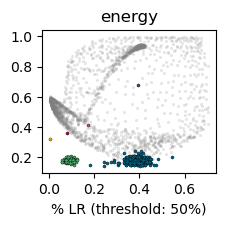

Save path:  /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/pca_results


In [ ]:
for idx, col in enumerate(cols_of_interest):
    fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

    plt.scatter(df_gnm_g["proportion_long_range_connections_0.5"], df_gnm_g[col], 
               color="gray", linewidth=0, s=5, alpha=0.2) 

    if len(col) > 20:
        col_for_title = re.split(r'[,,_]+', col)
        len_col = len(col_for_title)
        col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

    if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
        col = "min_value"
        col_for_title = "Distance Measure"
    
    for dataset in dict_with_all_merged_datasets.keys():

        # Skip the gnm dataset, as it will now have two eta and gamma columns. 
        if dataset == "hcp_schaefer_100_dataset_gnm":
            continue

        df_merged = dict_with_all_merged_datasets[dataset]

        if col in df_merged.columns:
            plt.scatter(df_merged["proportion_long_range_connections_0.5"], # df_merged["eta"], df_merged['gamma'],
                       df_merged[col],
                    #    c = df_merged[col],
                       edgecolor="black",
                       color=COLOR_SCHEME[dataset],
                       linewidth=0.25, s=5)
    
    plt.xlabel("% LR (threshold: 50%)") # Percentage of\nLR connections (> 50 % length)")
    # plt.ylabel(col.replace("_", " ").capitalize())
    # if the title is too long (define this), then split it into two lines at the last underscore
    plt.title(col) # , fontsize=6)
    
    plt.tight_layout()
    plt.savefig(output_folder / f"fig_{idx}_{col}_scatter.png", dpi=200)
    if idx == 0:
        plt.show()
    else: 
        plt.close()

print("Save path: ", output_folder)

In [ ]:
df_gnm_g

,eta,gamma,energy,avg_communicability,avg_edge_distance,wiring_cost,char_path_length,richclub_n_edges,richclub_avg_length,mc_mean,...,persistent_homology_ph_total_persistence,targeted_attack_robustness_rob_targeted_auc,targeted_attack_robustness_rob_random_auc,targeted_attack_robustness_rob_ratio,targeted_attack_robustness_rob_targeted_half,targeted_attack_robustness_rob_random_half,algebraic_connectivity_fiedler_value,algebraic_connectivity_fiedler_value_norm,algebraic_connectivity_laplacian_spectral_gap,algebraic_connectivity_fiedler_bipartition_balance
0,-8.0,-0.100000,0.931,0.015520,68.912802,34111.837109,2.237475,35.3,74.740613,8.379198,...,221.65,0.44869,0.485927,0.923368,0.487,0.4983,2.666178,0.133791,0.812038,0.468
1,-8.0,-0.077551,0.934,0.015567,68.775390,34043.817578,2.238646,37.1,69.670481,8.407290,...,221.60,0.45505,0.486249,0.935839,0.491,0.4969,2.440664,0.123242,0.711938,0.440
2,-8.0,-0.055102,0.939,0.015572,68.838924,34075.267188,2.234909,39.2,72.679114,8.320874,...,221.55,0.45774,0.486455,0.940996,0.493,0.4981,3.068431,0.152928,0.871220,0.638
3,-8.0,-0.032653,0.933,0.015549,68.495776,33905.408984,2.235697,37.8,67.709734,8.379292,...,221.35,0.45647,0.486966,0.937376,0.493,0.4985,3.019175,0.153873,0.870720,0.638
4,-8.0,-0.010204,0.936,0.015602,69.017478,34163.651563,2.235172,35.9,69.975212,8.336929,...,222.90,0.45472,0.486586,0.934556,0.487,0.4976,2.993023,0.151654,0.880869,0.610
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,3.0,0.910204,0.326,0.008264,71.699420,35491.212891,5.133980,128.4,83.668096,6.750237,...,99.00,0.35920,0.362585,0.992445,0.339,0.3015,0.019267,0.000615,0.330887,0.478
2496,3.0,0.932653,0.317,0.008387,73.086583,36177.858594,4.907172,126.9,84.562829,6.856519,...,99.00,0.35498,0.366310,0.977248,0.344,0.3065,0.022783,0.000728,0.341379,0.460
2497,3.0,0.955102,0.338,0.008264,73.510998,36387.944141,5.132020,126.7,84.072289,6.675188,...,99.00,0.35127,0.357857,0.987608,0.333,0.2983,0.021020,0.000681,0.392371,0.452
2498,3.0,0.977551,0.313,0.008357,73.208488,36238.201172,4.634364,123.8,85.426667,6.802856,...,99.00,0.34037,0.369171,0.929514,0.319,0.3097,0.033159,0.001035,0.414867,0.426


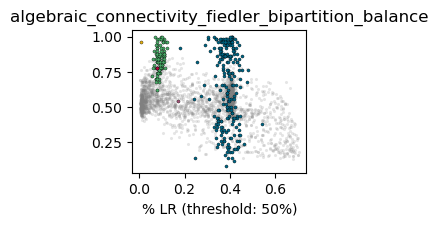

In [ ]:

fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

plt.scatter(df_gnm_g["proportion_long_range_connections_0.5"], df_gnm_g[col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in dict_with_all_merged_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_merged_datasets[dataset]

    if col in df_merged.columns:
        plt.scatter(df_merged["proportion_long_range_connections_0.5"], # df_merged["eta"], df_merged['gamma'],
                    df_merged[col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    linewidth=0.25, s=5)

plt.xlabel("% LR (threshold: 50%)") # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.title(col) # , fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_60321/4243622788.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


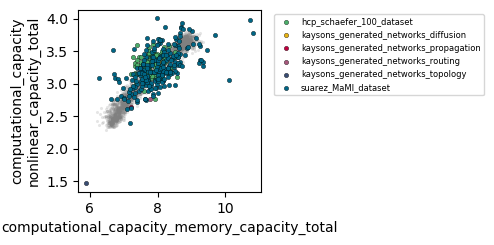

In [ ]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "computational_capacity_memory_capacity_total"
y_col = "computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in dict_with_all_merged_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_merged_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_60321/2713361139.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


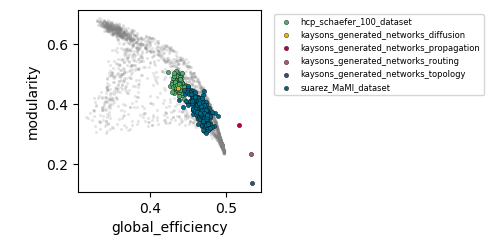

In [ ]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "global_efficiency" # computational_capacity_memory_capacity_total"
y_col = "modularity" # computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in dict_with_all_merged_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_merged_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_60321/4175181855.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


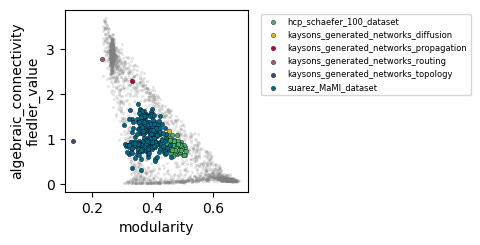

In [ ]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "modularity" # computational_capacity_memory_capacity_total"
y_col = "algebraic_connectivity_fiedler_value" # computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in dict_with_all_merged_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_merged_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_60321/524503894.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout() # TODO: INCLUDE IN DOCS


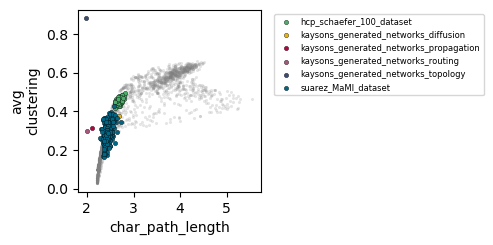

In [ ]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "char_path_length" # modularity" # computational_capacity_memory_capacity_total"
y_col = "avg_clustering" # algebraic_connectivity_fiedler_value" # computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in dict_with_all_merged_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_merged_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black", 
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout() # TODO: INCLUDE IN DOCS

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_60321/2386160329.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


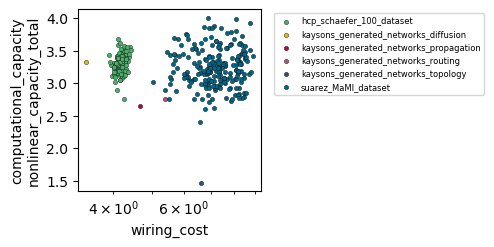

In [ ]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "wiring_cost"
y_col = "computational_capacity_nonlinear_capacity_total"
# plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
#             color="gray", linewidth=0, s=5, alpha=0.2) 

# if len(col) > 20:
#     col_for_title = re.split(r'[,,_]+', y_col)
#     len_col = len(col_for_title)
#     col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

# if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
#     col = "min_value"
#     col_for_title = "Distance Measure"

for dataset in dict_with_all_merged_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_merged_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_60321/611676436.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


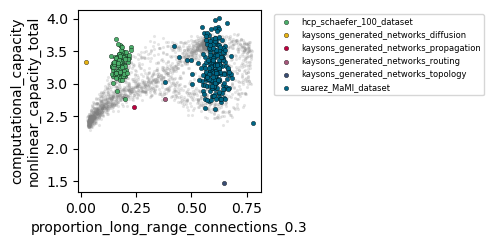

In [ ]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "proportion_long_range_connections_0.3" # wiring_cost"
y_col = "computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in dict_with_all_merged_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_merged_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_60321/4243622788.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


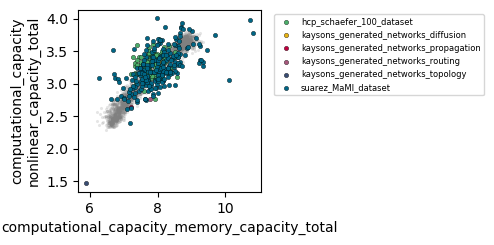

In [ ]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "computational_capacity_memory_capacity_total"
y_col = "computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in dict_with_all_merged_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_merged_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

# OLD


In [ ]:

plt.figure(figsize=viz.cm_to_inch((12,12)))

for dataset_name in dict_with_all_datasets:
    print(dataset_name)
    df = dict_with_all_datasets[dataset_name]
    print(df["wiring_cost"].shape)
    if dataset_name == "hcp_schaefer_100_dataset_gnm": 
        plt.scatter(df["wiring_cost"], df["computational_capacity_nonlinear_capacity_total"], c=df["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"], cmap=gray_cmap, s=5, alpha=0.2, linewidths=0, label=dataset_name)
    else: 
        print(COLOR_SCHEME[dataset_name])
        plt.scatter(df["wiring_cost"], df["computational_capacity_nonlinear_capacity_total"], s=10, label=dataset_name, marker="o", color=COLOR_SCHEME[dataset_name], linewidths=0.25, edgecolors="black")


# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

hcp_schaefer_100_dataset_gnm
(25000,)


KeyError: 'MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)'

<Figure size 472.441x472.441 with 0 Axes>

In [ ]:

plt.figure(figsize=viz.cm_to_inch((12,12)))

for dataset_name in dict_with_all_datasets:
    print(dataset_name)
    df = dict_with_all_datasets[dataset_name]
    print(df["wiring_cost"].shape)
    if dataset_name == "hcp_schaefer_100_dataset_gnm": 
        pass
        # plt.scatter(df["wiring_cost"], df["wiring_cost_dupa"], c=df["MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)"], cmap=gray_cmap, s=5, alpha=0.2, linewidths=0, label=dataset_name)
    else: 
        print(COLOR_SCHEME[dataset_name])
        plt.scatter(df["wiring_cost"], df["avg_communicability"], s=10, label=dataset_name, marker="o", color=COLOR_SCHEME[dataset_name], linewidths=0.25, edgecolors="black")


# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

In [ ]:

# --- Single scatter: wiring_cost vs computational capacity ---
fig, ax = plt.subplots(figsize=(10, 7))
for dataset_name, df in dict_with_all_datasets.items():
    if "wiring_cost" in df.columns and "computational_capacity_nonlinear_capacity_total" in df.columns:
        
        if dataset_name == "hcp_schaefer_100_dataset_gnm":
            ax.scatter(
                df["wiring_cost"],
                df["computational_capacity_nonlinear_capacity_total"],
                label=LABEL_MAP.get(dataset_name, dataset_name),
                color=COLOR_SCHEME.get(dataset_name, "gray"),
                # marker=MARKER_MAP.get(dataset_name, "o"),
                alpha=0.6,
                edgecolors="k",
                linewidths=0.3,
                s=30,
            )
        else:
            ax.scatter(
                df["wiring_cost"],
                df["computational_capacity_nonlinear_capacity_total"],
                label=LABEL_MAP.get(dataset_name, dataset_name),
                color=COLOR_SCHEME.get(dataset_name, "gray"),
                # marker=MARKER_MAP.get(dataset_name, "o"),
                alpha=0.6,
                edgecolors="k",
                linewidths=0.3,
                s=30,
            )
            
ax.set_xlabel("Wiring Cost", fontsize=12)
ax.set_ylabel("Computational Capacity (Nonlinear Total)", fontsize=12)
ax.set_title("Wiring Cost vs. Computational Capacity", fontsize=14)
ax.legend(fontsize=9, framealpha=0.9)
sns.despine()
plt.tight_layout()

plt.savefig(output_folder / "scatter_wiring_vs_comp_capacity.png", dpi=200)
print(output_folder / "scatter_wiring_vs_comp_capacity.png")
plt.show()


In [ ]:
shared_numeric_cols = None
for df in dict_with_all_datasets.values():
    numeric_cols = set(df.select_dtypes(include=[np.number]).columns)
    if shared_numeric_cols is None:
        shared_numeric_cols = numeric_cols
    else:
        shared_numeric_cols = shared_numeric_cols & numeric_cols

for col in shared_numeric_cols: 
    print(col)